# Imports

In [71]:
import pandas as pd
import re
import bibtexparser
import pycountry
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import plotly.express as px


# Loading Data

In [72]:


# Load bibtex file
with open("251211_scopus_export.bib", encoding="utf-8") as bibtex_file:
    bib_database = bibtexparser.load(bibtex_file)

# Convert to DataFrame
df = pd.DataFrame(bib_database.entries)
df.head()


,note,source,publication_stage,type,correspondence_address,affiliations,url,doi,pages,number,volume,journal,year,title,author,ENTRYTYPE,ID,keywords
0,Cited by: 0,Scopus,Final,Article,"V. Singh; School of Management, National Insti...","National Institute of Technology Rourkela, Sch...",https://www.scopus.com/inward/record.uri?eid=2...,10.1057/s41264-025-00338-3,,1,31,Journal of Financial Services Marketing,2026,CBDC in a privacy sensitive world: extending U...,"Singh, Vikrant and Yadav, Mayank and Gupta, As...",article,Singh2026,NaN
1,Cited by: 0,Scopus,Final,Article,P.N. Kemala; School of Business and Management...,"Institut Teknologi Bandung, Bandung, West Java...",https://www.scopus.com/inward/record.uri?eid=2...,10.1007/s42521-025-00166-z,,1,8,Digital Finance,2026,Advancing inclusive finance through financial ...,"Kemala, Prodia Nur and Koesrindartoto, Deddy P...",article,Kemala2026,NaN
2,Cited by: 0; All Open Access; Hybrid Gold Open...,Scopus,Final,Article,Y. Okhrin; Chair of Statistics and Data Scienc...,"Institute for Employment Research, Nuremberg, ...",https://www.scopus.com/inward/record.uri?eid=2...,10.1016/j.eswa.2025.129555,,NaN,298,Expert Systems with Applications,2026,A spectral relevance analysis approach to patt...,"Distler, Christine and Okhrin, Yarema and Pfah...",article,Distler2026,Computer vision; Convolutional neural networks...
3,Cited by: 0,Scopus,Final,Article,J. Wang; Tianjin Key Laboratory for Control Th...,"Tianjin University of Technology, Tianjin, Tia...",https://www.scopus.com/inward/record.uri?eid=2...,10.1016/j.apm.2025.116483,,NaN,150,Applied Mathematical Modelling,2026,Modeling the blockchain-related insurance cont...,"Chen, Tingyu and Wang, Juan and Wang, Song and...",article,Chen2026,Cost benefit analysis; Cost functions; Cost re...
4,Cited by: 0,Scopus,Final,Article,W. Han; Computation and Artificial Intelligenc...,"Fudan University, College of Computer Science ...",https://www.scopus.com/inward/record.uri?eid=2...,10.1016/j.eswa.2025.128900,,NaN,296,Expert Systems with Applications,2026,ETTracker: A fund tracking framework for anti-...,"Wu, Changhao and Xu, Junwei and Wang, Kai and ...",article,Wu2026,Decentralized finance; Directed graphs; Intern...


In [73]:
df.columns

Index(['note', 'source', 'publication_stage', 'type', 'correspondence_address',
       'affiliations', 'url', 'doi', 'pages', 'number', 'volume', 'journal',
       'year', 'title', 'author', 'ENTRYTYPE', 'ID', 'keywords'],
      dtype='object')

# Trend

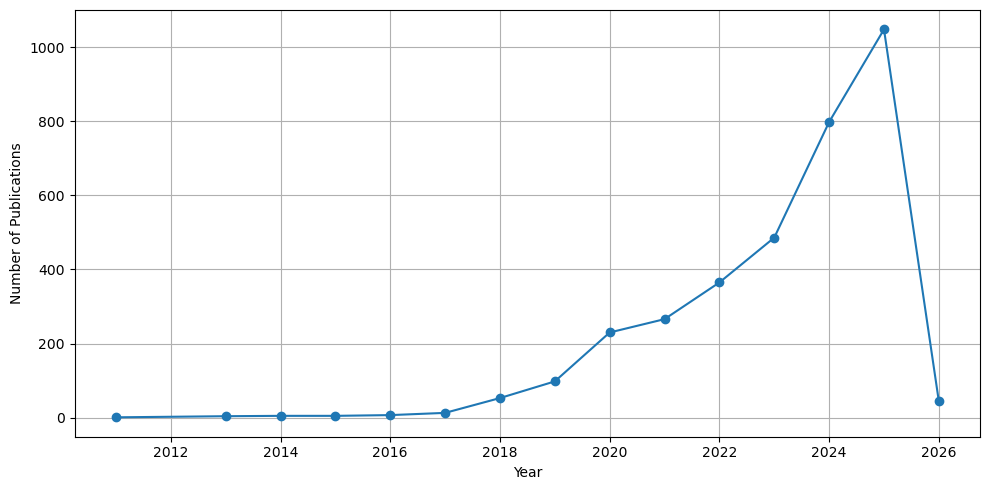

In [74]:


# Ensure year is integer
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

# Drop rows with missing year (just in case)
df_year = df.dropna(subset=["year"])

# Group by year
pubs_per_year = df_year.groupby("year").size()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(pubs_per_year.index, pubs_per_year.values, marker="o")
#plt.title("Publications per Year")
plt.xlabel("Year")
plt.ylabel("Number of Publications")
plt.grid(True)
plt.tight_layout()
plt.show()


# Location

In [75]:


# Official country names (lowercase → canonical name)
COUNTRY_NAMES = {c.name.lower(): c.name for c in pycountry.countries}

# Optional: add a few common aliases / variants
ALIASES = {
    "usa": "United States",
    "u.s.a.": "United States",
    "united states": "United States",
    "united states of america": "United States",
    "uk": "United Kingdom",
    "u.k.": "United Kingdom",
    "england": "United Kingdom",
    "scotland": "United Kingdom",
    "wales": "United Kingdom",
    "russia": "Russian Federation",
    "south korea": "Korea, Republic of",
    "north korea": "Korea, Democratic People's Republic of",
    "iran": "Iran, Islamic Republic of",
    "vietnam": "Viet Nam",
}




In [76]:
def extract_countries_from_affiliations(affil_text):
    """
    Extract a list of country names from a Scopus-style affiliations string.
    Returns a list of canonical country names (could be empty).
    """
    if not isinstance(affil_text, str) or affil_text.strip() == "":
        return []
    
    # Split on comma or semicolon; process from the end (where countries usually appear)
    parts = re.split(r"[;,]", affil_text)
    parts = [p.strip().lower() for p in parts if p.strip() != ""]
    
    found = []
    
    # Process from the end to catch countries like "... City, Province, Country"
    for part in reversed(parts):
        # Exact match to official country name
        if part in COUNTRY_NAMES:
            canon = COUNTRY_NAMES[part]
            if canon not in found:
                found.append(canon)
        
        # Alias match (e.g. "usa", "uk")
        elif part in ALIASES:
            canon = ALIASES[part]
            if canon not in found:
                found.append(canon)
    
    # Return in original order of appearance (earliest country first)
    return list(reversed(found))


In [77]:
df["countries_all"] = df["affiliations"].apply(extract_countries_from_affiliations)

# Main country for analysis: first country in the list (if any)
df["country_first"] = df["countries_all"].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)


In [78]:
df[["affiliations", "countries_all", "country_first"]].head(10)


,affiliations,countries_all,country_first
0,"National Institute of Technology Rourkela, Sch...",[India],India
1,"Institut Teknologi Bandung, Bandung, West Java...",[Indonesia],Indonesia
2,"Institute for Employment Research, Nuremberg, ...",[Germany],Germany
3,"Tianjin University of Technology, Tianjin, Tia...",[China],China
4,"Fudan University, College of Computer Science ...",[China],China
5,"Amrita School of Business, Coimbatore, TN, India",[India],India
6,NaN,[],None
7,"Xi'an Jiaotong-Liverpool University, School of...","[China, Spain]",China
8,"Walchand Institute of Technology, Solapur, Dep...","[India, Russian Federation]",India
9,"University of Craiova, PhD School, Craiova, Do...",[Romania],Romania


In [79]:
df_heat = df.dropna(subset=["country_first", "year"])

counts = (
    df_heat
    .groupby(["country_first", "year"])
    .size()
    .reset_index(name="n")
)
pivot = counts.pivot(index="country_first", columns="year", values="n").fillna(0)

top_countries = df_heat["country_first"].value_counts().head(15).index
pivot = pivot.loc[top_countries]


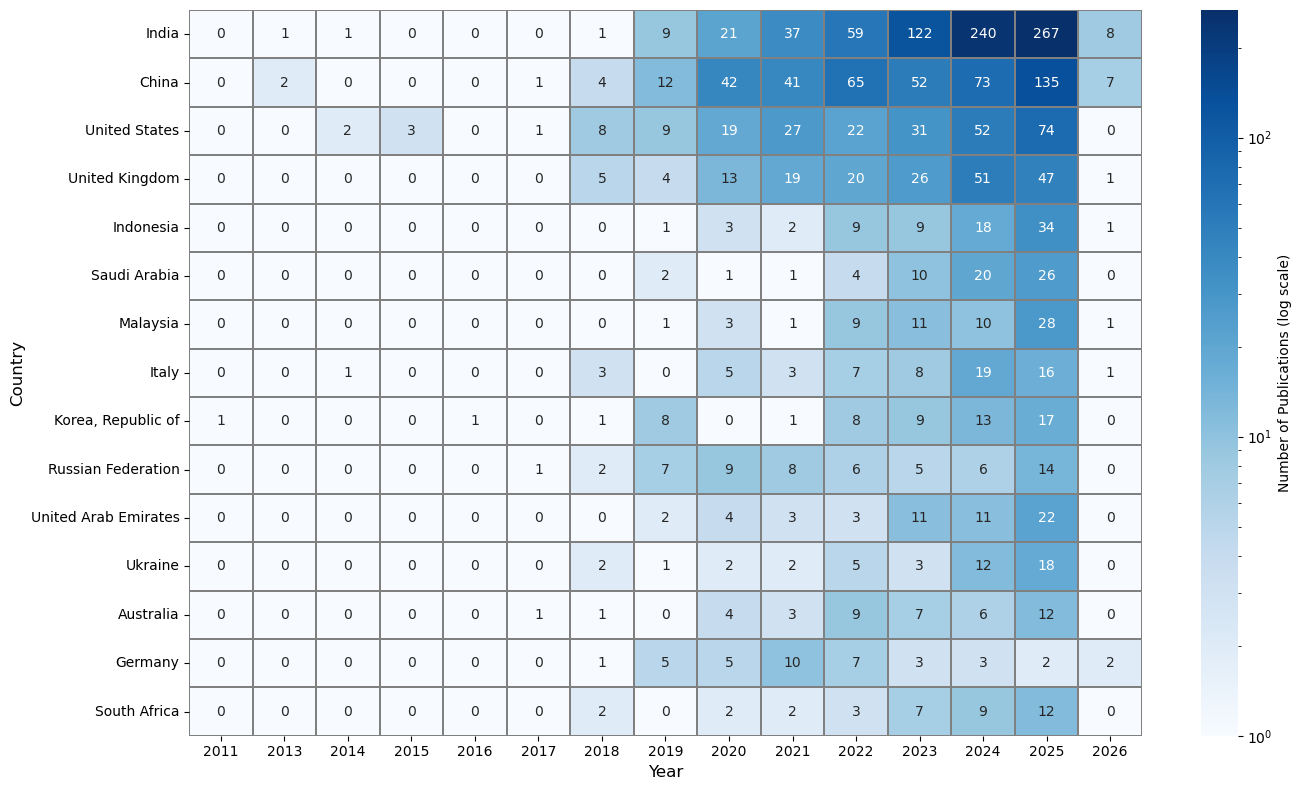

In [80]:


# Replace zero values ONLY for the color scale (log can't handle 0)
pivot_for_colors = pivot.replace(0, 1)

plt.figure(figsize=(14, 8))

sns.heatmap(
    pivot_for_colors,
    cmap="Blues",
    norm=LogNorm(vmin=1, vmax=pivot_for_colors.max().max()),
    linewidths=0.3,
    linecolor="gray",
    annot=pivot,     # annotate using the ORIGINAL values (with zeros)
    fmt=".0f",
    cbar_kws={"label": "Number of Publications (log scale)"}
)

#plt.title("Publications by Country and Year (Log Scale)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Country", fontsize=12)

plt.tight_layout()
plt.show()


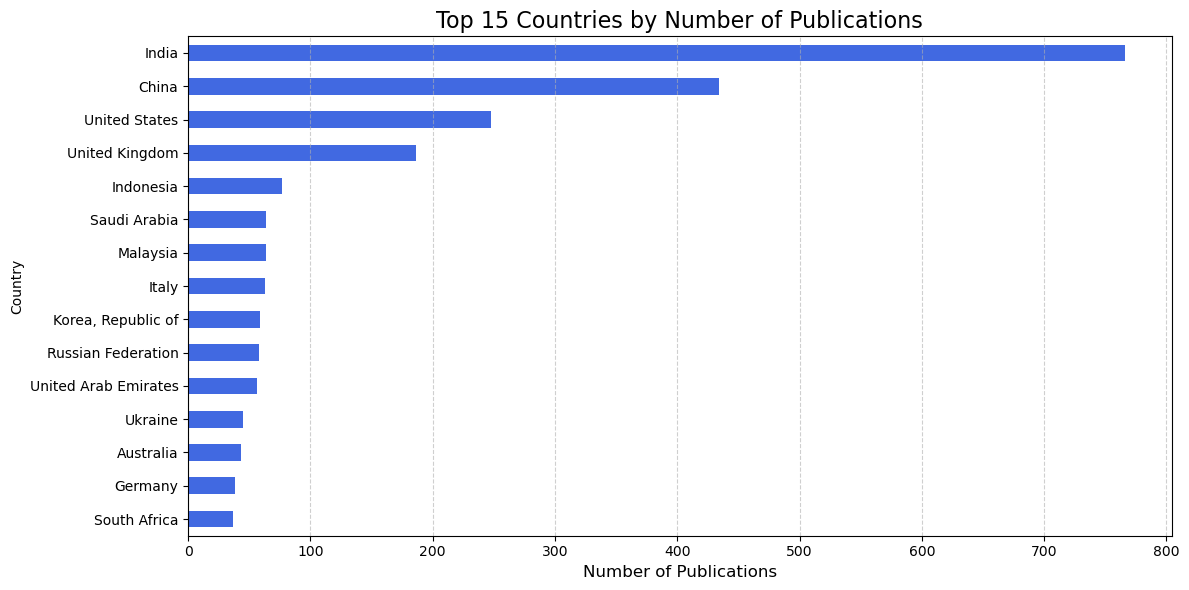

In [81]:
# Count overall output by country
country_counts = df['country_first'].value_counts().head(15)

plt.figure(figsize=(12, 6))
country_counts.plot(kind='barh', color="royalblue")

plt.title("Top 15 Countries by Number of Publications", fontsize=16)
plt.xlabel("Number of Publications", fontsize=12)
plt.ylabel("Country")

plt.gca().invert_yaxis()  # largest at the top
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [82]:

# --- 1. Prepare the dataset ---

# Count publications per country per year
df_map = (
    df_geo.groupby(["country_first", "year"])
          .size()
          .reset_index(name="n")
          .dropna(subset=["year"])
)

# Ensure year is numeric and sorted
df_map["year"] = df_map["year"].astype(int)
df_map = df_map.sort_values("year")

# --- 2. Create the animated world map ---

fig = px.choropleth(
    df_map,
    locations="country_first",
    locationmode="country names",
    color="n",
    animation_frame="year",
    color_continuous_scale="Blues",
    title="Global Diffusion of Digital Finance + ML Research Over Time"
)

# Explicitly sort animation frames (plotly sometimes needs this hint)
fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 700
fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["redraw"] = True

fig.show()


In [83]:

# Filter rows that have country and year values
df_geo = df.dropna(subset=["year", "country_first"]).copy()
df_geo["year"] = df_geo["year"].astype(int)

# Optional: limit to top N countries to keep the plot readable
TOP_N = 10
top_countries = df_geo["country_first"].value_counts().head(TOP_N).index

df_geo_top = df_geo[df_geo["country_first"].isin(top_countries)]

# Build pivot table: rows = years, columns = countries, values = publication counts
pivot_country_year = (
    df_geo_top
    .groupby(["year", "country_first"])
    .size()
    .reset_index(name="n")
    .pivot(index="year", columns="country_first", values="n")
    .fillna(0)
    .sort_index()
)


<Figure size 1400x800 with 0 Axes>

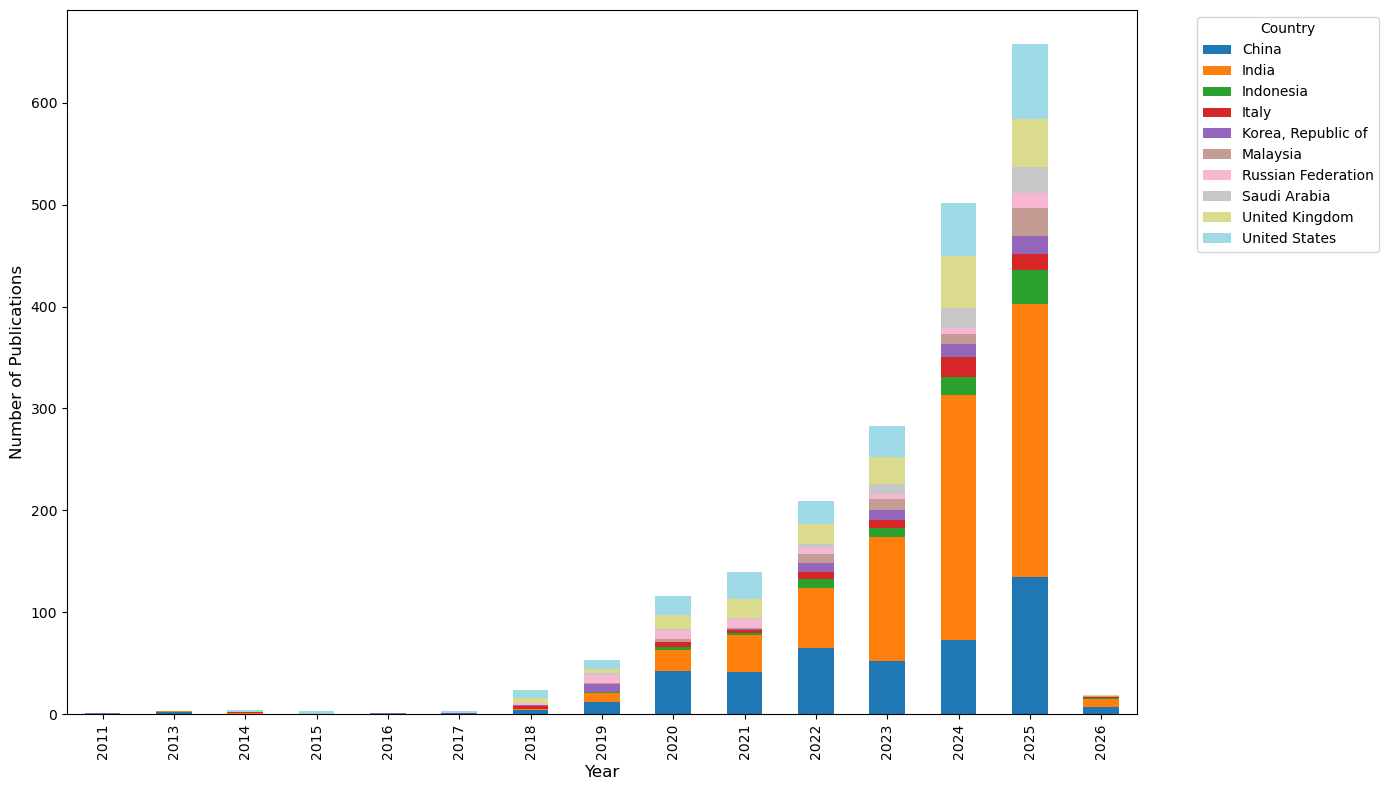

In [84]:
plt.figure(figsize=(14, 8))

pivot_country_year.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 8),
    colormap="tab20"
)

#plt.title("Stacked Publications per Country Over Time", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Publications", fontsize=12)
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


# Key Words

In [85]:
# Clean keywords: split, strip, lowercase
def clean_keywords(kw):
    if not isinstance(kw, str):
        return []
    return [k.strip().lower() for k in kw.split(";") if k.strip() != ""]
    
df["kw_list"] = df["keywords"].apply(clean_keywords)


In [86]:
df_kw = df.explode("kw_list")
df_kw = df_kw.dropna(subset=["year", "kw_list"])


In [87]:
kw_counts = df_kw["kw_list"].value_counts()

TOP_N = 15
top_keywords = kw_counts.head(TOP_N).index

df_kw_top = df_kw[df_kw["kw_list"].isin(top_keywords)]


In [88]:
pivot_kw = df_kw_top.groupby(["kw_list", "year"]).size().reset_index(name="n")

pivot_kw = pivot_kw.pivot(index="kw_list", columns="year", values="n").fillna(0)

# Sort years
pivot_kw = pivot_kw.reindex(sorted(pivot_kw.columns), axis=1)


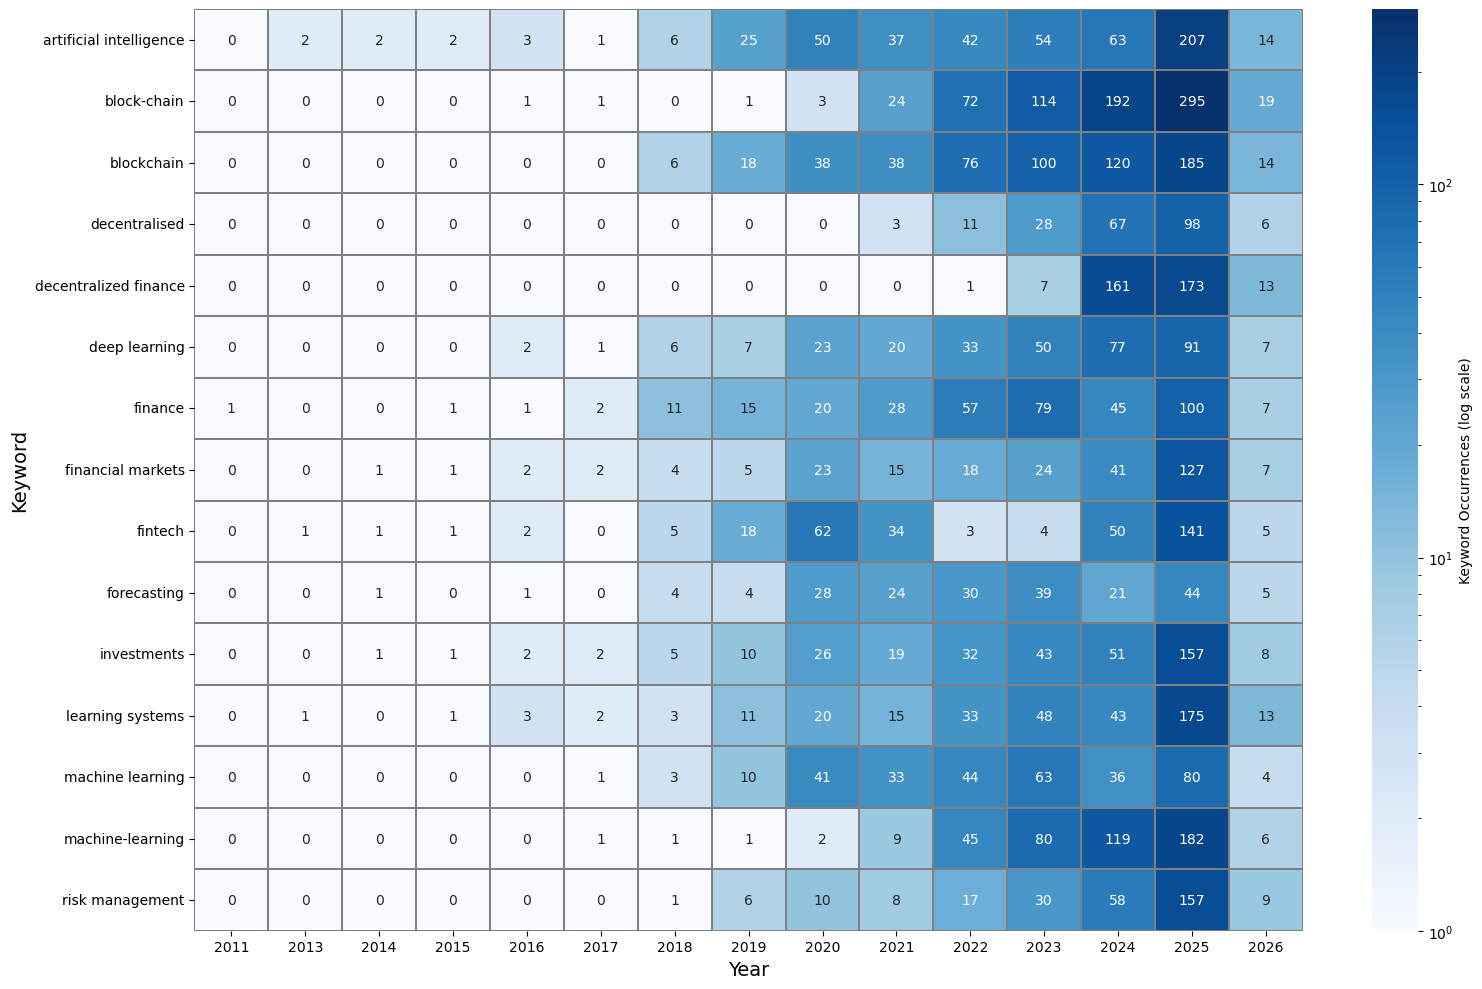

In [89]:


# Replace zero values ONLY for the color scale (log can't handle 0)
pivot_kw_for_colors = pivot_kw.replace(0, 1)

plt.figure(figsize=(16, 10))

sns.heatmap(
    pivot_kw_for_colors,
    cmap="Blues",
    norm=LogNorm(vmin=1, vmax=pivot_kw_for_colors.max().max()),
    linewidths=0.3,
    linecolor="gray",
    annot=pivot_kw,      # annotate using the ORIGINAL values (with zeros)
    fmt=".0f",
    cbar_kws={"label": "Keyword Occurrences (log scale)"}
)

#plt.title("Keyword Occurrences by Year (Top 15 Keywords, Log Scale)", fontsize=18)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Keyword", fontsize=14)

plt.tight_layout()
plt.show()
